# 📊 Notebook 1 — Data Exploration & Preprocessing
**Dataset:** Life Expectancy (WHO) — [Kaggle Source](https://www.kaggle.com/kumarajarshi/life-expectancy-who)

This notebook covers:
1. Library imports
2. Data loading & initial exploration
3. Missing value analysis & imputation
4. Outlier analysis
5. Encoding, feature engineering & normalization
6. Exploratory visualizations
7. Train/test split


## 1. Library Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from warnings import filterwarnings
filterwarnings('ignore')


## 2. Load Data

In [4]:
df = pd.read_csv('Life Expectancy Data.csv')
print("Shape:", df.shape)
df.head()


Shape: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Features:", df.shape[1])
df.info()


Number of Rows: 2938
Number of Features: 22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 

## 3. Missing Value Analysis

In [6]:
# Count missing values per column
df.isnull().sum()


Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

## 4. Statistical Summary

In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


## 5. Categorical Feature Exploration

In [8]:
print(df['Country'].value_counts())
print()
print(df['Status'].value_counts())


Country
Afghanistan              16
Albania                  16
Algeria                  16
Angola                   16
Antigua and Barbuda      16
                         ..
Monaco                    1
Marshall Islands          1
Saint Kitts and Nevis     1
San Marino                1
Tuvalu                    1
Name: count, Length: 193, dtype: int64

Status
Developing    2426
Developed      512
Name: count, dtype: int64


## 6. Data Cleaning

### 6.1 Impute Missing Values
Since the proportion of missing values is significant, we use mean imputation via `SimpleImputer`.


In [9]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

cols_to_impute = [
    'Life expectancy ', 'Adult Mortality', 'Alcohol', 'Hepatitis B',
    ' BMI ', 'Polio', 'Total expenditure', 'Diphtheria ', 'GDP',
    'Population', ' thinness  1-19 years', ' thinness 5-9 years',
    'Income composition of resources', 'Schooling'
]

for col in cols_to_impute:
    df[col] = imputer.fit_transform(df[[col]])

print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64


### 6.2 Remove Duplicates

In [10]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (2938, 22)


### 6.3 Outlier Analysis
We visualize outliers via box plots. We do **not** remove them — extreme values
(e.g. very high population in large countries) are legitimate data points.


In [11]:
# Box plots for each numeric column
numeric_cols = df.select_dtypes(include='number').columns

for column in numeric_cols:
    fig = px.box(df, y=column, title=f'<b>Box Plot — {column}</b>',
                 template='plotly_dark')
    fig.update_layout(title_x=0.5)
    fig.show()


## 7. Encoding & Feature Engineering

In [12]:
# Encode 'Status': Developed=0, Developing=1
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])
df['Status'].value_counts()


Status
1    2426
0     512
Name: count, dtype: int64

## 8. Exploratory Visualizations

In [13]:
# Distribution of target variable
fig = px.histogram(df, x='Life expectancy ', template='plotly_dark',
                   title='<b>Distribution of Life Expectancy</b>')
fig.show()


In [14]:
# Life expectancy trend over years per country
fig = px.line(
    df.sort_values(by='Year'),
    x='Year', y='Life expectancy ',
    animation_frame='Country', animation_group='Year',
    color='Country', markers=True,
    template='plotly_dark',
    title='<b>Country-wise Life Expectancy Over Years</b>'
)
fig.show()


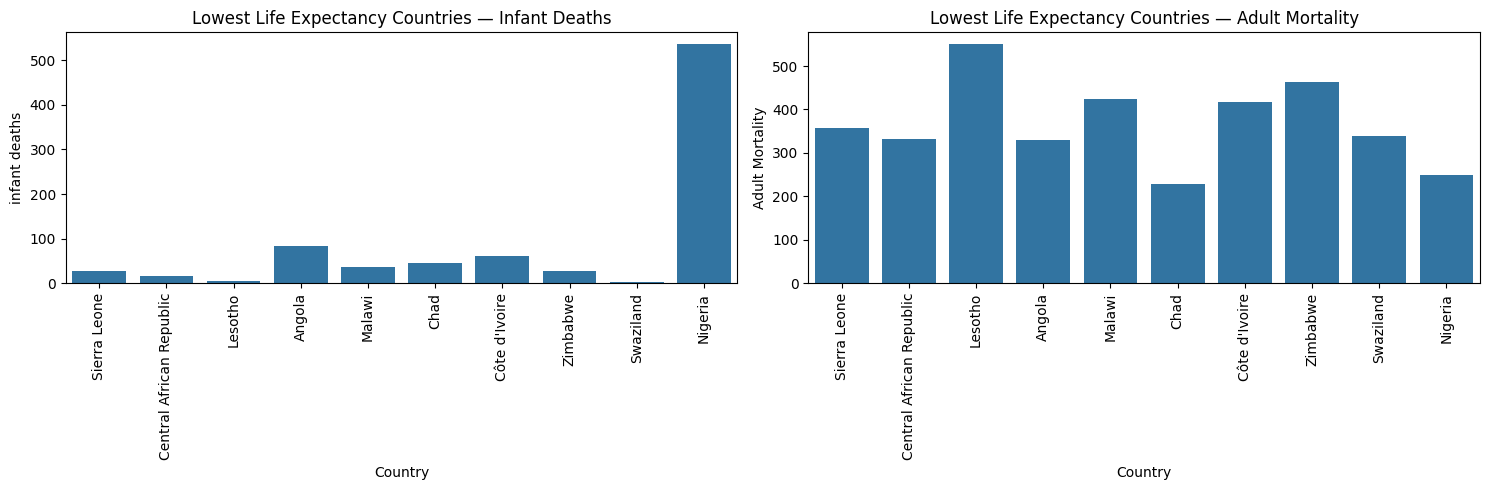

In [15]:
# Top 10 countries with lowest average life expectancy
low_life = df.groupby('Country').mean().nsmallest(10, 'Life expectancy ').reset_index()

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=low_life, x='Country', y='infant deaths')
ax1.set_title("Lowest Life Expectancy Countries — Infant Deaths")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=low_life, x='Country', y='Adult Mortality')
ax2.set_title("Lowest Life Expectancy Countries — Adult Mortality")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()


## 9. Correlation Analysis & Feature Selection

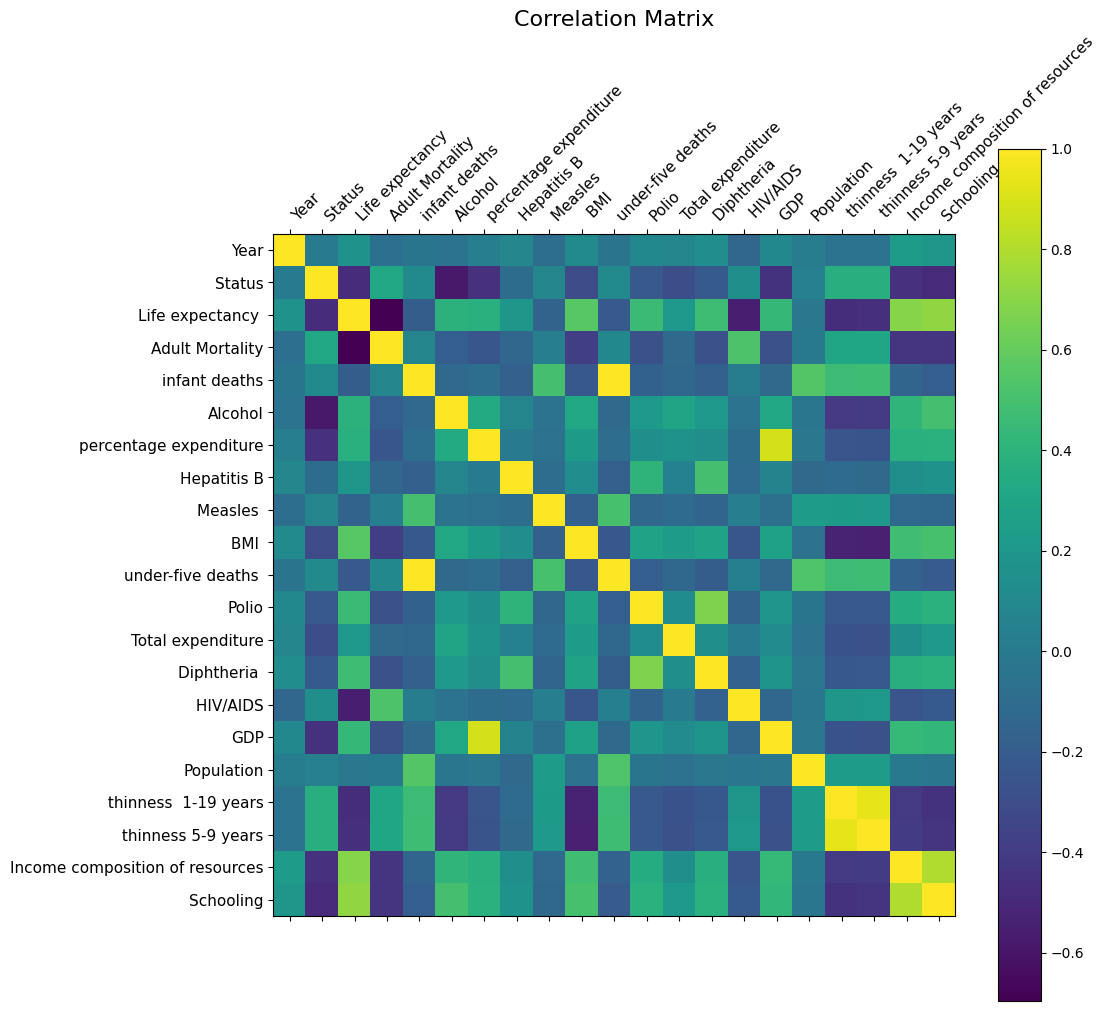

In [16]:
# Drop 'Country' — high cardinality, not useful for modelling
df.drop('Country', axis=1, inplace=True)

# Correlation matrix
f = plt.figure(figsize=(11, 11))
plt.matshow(df.corr(), fignum=f.number)
cols = df.select_dtypes('number').columns
plt.xticks(range(len(cols)), cols, fontsize=11, ha='left', rotation=45)
plt.yticks(range(len(cols)), cols, fontsize=11)
plt.colorbar().ax.tick_params(labelsize=10)
plt.title('Correlation Matrix', fontsize=16)
plt.show()


In [17]:
# Remove highly correlated redundant features:
# 'under-five deaths' ≈ 'infant deaths'
# ' thinness 1-19 years' ≈ ' thinness 5-9 years'
df.drop(columns=['under-five deaths ', ' thinness  1-19 years'], inplace=True)
print("Remaining columns:", df.columns.tolist())


Remaining columns: ['Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']


## 10. Feature / Target Split & Scaling

In [18]:
X = df.drop('Life expectancy ', axis=1)
y = df['Life expectancy ']

# MinMax scaling — brings heterogeneous ranges to [0, 1]
cols_to_scale = [c for c in X.columns if c != 'Status']
scaler = MinMaxScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

X.head()


,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 5-9 years,Income composition of resources,Schooling
0,1.000000,1,0.362881,0.034444,0.0,0.003659,0.653061,0.005439,0.209733,0.031250,0.452118,0.649485,0.0,0.004889,0.026074,0.603509,0.505274,0.487923
1,0.933333,1,0.373961,0.035556,0.0,0.003774,0.622449,0.002319,0.203940,0.572917,0.453279,0.618557,0.0,0.005127,0.000253,0.610526,0.502110,0.483092
2,0.866667,1,0.369806,0.036667,0.0,0.003759,0.642857,0.002027,0.198146,0.614583,0.450377,0.639175,0.0,0.005287,0.024525,0.617544,0.495781,0.478261
3,0.800000,1,0.375346,0.038333,0.0,0.004014,0.673469,0.013135,0.192352,0.666667,0.473012,0.670103,0.0,0.005608,0.002857,0.628070,0.488397,0.473430
4,0.733333,1,0.379501,0.039444,0.0,0.000364,0.683673,0.014200,0.187717,0.677083,0.435287,0.680412,0.0,0.000519,0.002302,0.635088,0.478903,0.458937


## 11. Train / Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (2350, 18)
X_test : (588, 18)
y_train: (2350,)
y_test : (588,)


## ✅ Output
`X_train`, `X_test`, `y_train`, `y_test` are ready.
Save them for use in the modelling notebooks:


In [20]:
import pickle, os
os.makedirs('data', exist_ok=True)
with open('data/splits.pkl', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)
print("Splits saved to data/splits.pkl")


Splits saved to data/splits.pkl
